# Solar Power Forecasting With LSTM

Notebook này xây dựng một mô hình `LSTM` để dự đoán sản lượng điện mặt trời từ bộ dữ liệu của hai nhà máy. Khác với mô hình Random Forest trong notebook trước, LSTM được thiết kế cho dữ liệu chuỗi thời gian và có khả năng học phụ thuộc theo thứ tự thời gian giữa các quan sát.

Mục tiêu của notebook:
- Đọc và làm sạch dữ liệu của cả hai nhà máy.
- Ghép dữ liệu phát điện với dữ liệu cảm biến thời tiết.
- Chuyển dữ liệu tabular thành dữ liệu chuỗi bằng kỹ thuật sliding window.
- Huấn luyện mô hình `LSTM` bằng PyTorch.
- Đánh giá mô hình bằng `MAE`, `RMSE`, `R2`.
- Trực quan hóa kết quả dự đoán để so sánh với giá trị thực tế.

## 1. Tại sao chọn LSTM cho bài toán này?

Bài toán dự đoán sản lượng điện mặt trời là một bài toán chuỗi thời gian. Công suất phát điện tại thời điểm hiện tại không chỉ phụ thuộc vào thời tiết hiện tại, mà còn có liên hệ với các thời điểm trước đó. Ví dụ, cường độ bức xạ và nhiệt độ module thường thay đổi liên tục chứ không nhảy ngẫu nhiên hoàn toàn giữa các mốc 15 phút.

`LSTM` là một biến thể của Recurrent Neural Network (RNN), được thiết kế để ghi nhớ thông tin theo chuỗi và giảm vấn đề mất gradient khi chuỗi dài. Trong bài toán này, ta sẽ cho mô hình nhìn vào một đoạn lịch sử gần nhất, ví dụ 12 mốc thời gian trước, để dự đoán `AC_POWER_TOTAL` ở mốc kế tiếp.

Ý tưởng tổng quát:
- Mỗi mẫu huấn luyện là một chuỗi thời gian ngắn gồm nhiều bước liên tiếp.
- Mỗi bước trong chuỗi chứa các feature thời tiết và feature thời gian.
- Mô hình học cách ánh xạ từ lịch sử gần nhất sang sản lượng điện tương lai.

In [2]:
from pathlib import Path
import copy
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Đọc dữ liệu và chuẩn hóa định dạng thời gian

Bộ dữ liệu gồm 4 file CSV cho 2 nhà máy. Ta sẽ đọc từng cặp `generation` và `weather`, sau đó chuẩn hóa cột `DATE_TIME` để đảm bảo việc merge theo thời gian là chính xác.

Lưu ý quan trọng:
- Plant 1 trong bảng `generation` dùng định dạng ngày tháng kiểu `dd-mm-YYYY HH:MM`.
- Plant 2 trong bảng `generation` đã ở định dạng timestamp chuẩn hơn.
- Dữ liệu `weather` của cả hai plant dùng định dạng timestamp chuẩn.

Nếu bỏ qua sự khác biệt này, việc ghép bảng có thể thất bại hoặc tạo ra nhiều giá trị thiếu.

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'datasets'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

def resolve_dataset_path(filename: str) -> Path:
    candidate = DATA_DIR / filename
    if candidate.exists():
        return candidate
    candidate = BASE_DIR / filename
    if candidate.exists():
        return candidate
    raise FileNotFoundError(filename)

def load_plant_data(plant_no: int):
    generation = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Generation_Data.csv'))
    weather = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Weather_Sensor_Data.csv'))

    if plant_no == 1:
        generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'], format='%d-%m-%Y %H:%M', errors='coerce')
    else:
        generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'], errors='coerce')

    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], errors='coerce')

    generation['PLANT_NO'] = plant_no
    weather['PLANT_NO'] = plant_no

    generation = generation.sort_values(['DATE_TIME', 'SOURCE_KEY']).reset_index(drop=True)
    weather = weather.sort_values('DATE_TIME').reset_index(drop=True)
    return generation, weather

plant_1_gen, plant_1_weather = load_plant_data(1)
plant_2_gen, plant_2_weather = load_plant_data(2)

print('Plant 1 generation:', plant_1_gen.shape)
print('Plant 1 weather   :', plant_1_weather.shape)
print('Plant 2 generation:', plant_2_gen.shape)
print('Plant 2 weather   :', plant_2_weather.shape)

Plant 1 generation: (68778, 8)
Plant 1 weather   : (3182, 7)
Plant 2 generation: (67698, 8)
Plant 2 weather   : (3259, 7)


## 3. Khám phá nhanh chất lượng dữ liệu

Trước khi xây dựng mô hình, ta cần chắc chắn dữ liệu đủ sạch để dùng cho chuỗi thời gian. Các kiểm tra cơ bản gồm:
- Số lượng dòng và số lượng mốc thời gian.
- Giá trị thiếu ở từng cột.
- Số lượng inverter hoặc sensor.
- Khoảng thời gian bao phủ dữ liệu.

Khi làm việc với LSTM, dữ liệu bị thiếu hoặc bị lệch mốc thời gian có thể gây lỗi trong quá trình tạo sequence. Vì vậy bước kiểm tra này đặc biệt quan trọng.

In [4]:
def inspect_dataframe(name: str, df: pd.DataFrame):
    print(f'===== {name} =====')
    print('shape:', df.shape)
    print('missing values:')
    print(df.isna().sum())
    print('duplicate rows:', df.duplicated().sum())
    print('unique SOURCE_KEY:', df['SOURCE_KEY'].nunique())
    print('time range:', df['DATE_TIME'].min(), '->', df['DATE_TIME'].max())
    print()

inspect_dataframe('Plant 1 Generation', plant_1_gen)
inspect_dataframe('Plant 1 Weather', plant_1_weather)
inspect_dataframe('Plant 2 Generation', plant_2_gen)
inspect_dataframe('Plant 2 Weather', plant_2_weather)

===== Plant 1 Generation =====
shape: (68778, 8)
missing values:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
PLANT_NO       0
dtype: int64
duplicate rows: 0
unique SOURCE_KEY: 22
time range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00

===== Plant 1 Weather =====
shape: (3182, 7)
missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
PLANT_NO               0
dtype: int64
duplicate rows: 0
unique SOURCE_KEY: 1
time range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00

===== Plant 2 Generation =====
shape: (67698, 8)
missing values:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
PLANT_NO       0
dtype: int64
duplicate rows: 0
unique SOURCE_KEY: 22
time range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00

===== Plant 2 Weather =====
shape: (

## 4. Tổng hợp dữ liệu phát điện và merge với dữ liệu thời tiết

Bảng `generation` ghi nhận dữ liệu theo từng inverter, còn bảng `weather` chỉ có một sensor đại diện cho mỗi nhà máy. Vì vậy, ta cần tổng hợp dữ liệu `generation` lên mức nhà máy trước khi merge.

Cách làm:
1. Group theo `PLANT_ID`, `PLANT_NO`, `DATE_TIME`.
2. Tính tổng `AC_POWER`, `DC_POWER`, `DAILY_YIELD`, `TOTAL_YIELD`.
3. Ghép với `weather` theo `PLANT_ID`, `PLANT_NO`, `DATE_TIME`.

Sau bước này, mỗi dòng sẽ đại diện cho một nhà máy tại một mốc thời gian 15 phút, phù hợp để xây dựng chuỗi cho LSTM.

In [5]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['HOUR'] = out['DATE_TIME'].dt.hour
    out['MINUTE'] = out['DATE_TIME'].dt.minute
    out['DAYOFWEEK'] = out['DATE_TIME'].dt.dayofweek
    out['DAYOFYEAR'] = out['DATE_TIME'].dt.dayofyear
    out['MONTH'] = out['DATE_TIME'].dt.month
    hour_fraction = out['HOUR'] + out['MINUTE'] / 60.0
    out['HOUR_SIN'] = np.sin(2 * np.pi * hour_fraction / 24.0)
    out['HOUR_COS'] = np.cos(2 * np.pi * hour_fraction / 24.0)
    out['IS_DAYLIGHT'] = ((out['HOUR'] >= 6) & (out['HOUR'] <= 18)).astype(int)
    return out

def aggregate_generation(generation: pd.DataFrame) -> pd.DataFrame:
    aggregated = generation.groupby(['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], as_index=False).agg(
        AC_POWER_TOTAL=('AC_POWER', 'sum'),
        DC_POWER_TOTAL=('DC_POWER', 'sum'),
        DAILY_YIELD_TOTAL=('DAILY_YIELD', 'sum'),
        TOTAL_YIELD_TOTAL=('TOTAL_YIELD', 'sum'),
        ACTIVE_SOURCE_COUNT=('SOURCE_KEY', 'nunique')
    )
    return aggregated

def merge_generation_weather(generation: pd.DataFrame, weather: pd.DataFrame) -> pd.DataFrame:
    generation_agg = aggregate_generation(generation)
    weather_renamed = weather.rename(columns={'SOURCE_KEY': 'WEATHER_SENSOR_KEY'})
    merged = generation_agg.merge(
        weather_renamed,
        on=['PLANT_ID', 'PLANT_NO', 'DATE_TIME'],
        how='left'
    )
    merged = add_time_features(merged)
    return merged

plant_1_merged = merge_generation_weather(plant_1_gen, plant_1_weather)
plant_2_merged = merge_generation_weather(plant_2_gen, plant_2_weather)

all_merged = pd.concat([plant_1_merged, plant_2_merged], ignore_index=True)
all_merged = all_merged.sort_values(['PLANT_NO', 'DATE_TIME']).reset_index(drop=True)

print('Plant 1 merged:', plant_1_merged.shape)
print('Plant 2 merged:', plant_2_merged.shape)
print('All merged    :', all_merged.shape)

all_merged.head()

Plant 1 merged: (3158, 20)
Plant 2 merged: (3259, 20)
All merged    : (6417, 20)


,PLANT_ID,PLANT_NO,DATE_TIME,AC_POWER_TOTAL,DC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,WEATHER_SENSOR_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,MINUTE,DAYOFWEEK,DAYOFYEAR,MONTH,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000,0,0,4,136,5,0.0000,1.0000,0
1,4135001,1,2020-05-15 00:15:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000,0,15,4,136,5,0.0654,0.9979,0
2,4135001,1,2020-05-15 00:30:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000,0,30,4,136,5,0.1305,0.9914,0
3,4135001,1,2020-05-15 00:45:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,HmiyD2TTLFNqkNe,24.8461,22.3609,0.0000,0,45,4,136,5,0.1951,0.9808,0
4,4135001,1,2020-05-15 01:00:00,0.0000,0.0000,0.0000,"150,761,642.0000",22,HmiyD2TTLFNqkNe,24.6215,22.1654,0.0000,1,0,4,136,5,0.2588,0.9659,0


## 5. Khai phá dữ liệu sau khi merge

Sau khi merge, ta có thể trực quan hóa các biến quan trọng ở mức nhà máy. Điều này giúp kiểm tra xem `AC_POWER_TOTAL` có đi cùng với `IRRADIATION` như kỳ vọng hay không, đồng thời giúp so sánh đặc điểm giữa hai plant.

Ta sẽ vẽ:
- Công suất AC tổng theo ngày.
- Bức xạ mặt trời trung bình theo ngày.
- Nhiệt độ module trung bình theo ngày.

Các biểu đồ này vừa hỗ trợ EDA vừa giúp giải thích kết quả dự đoán sau này.

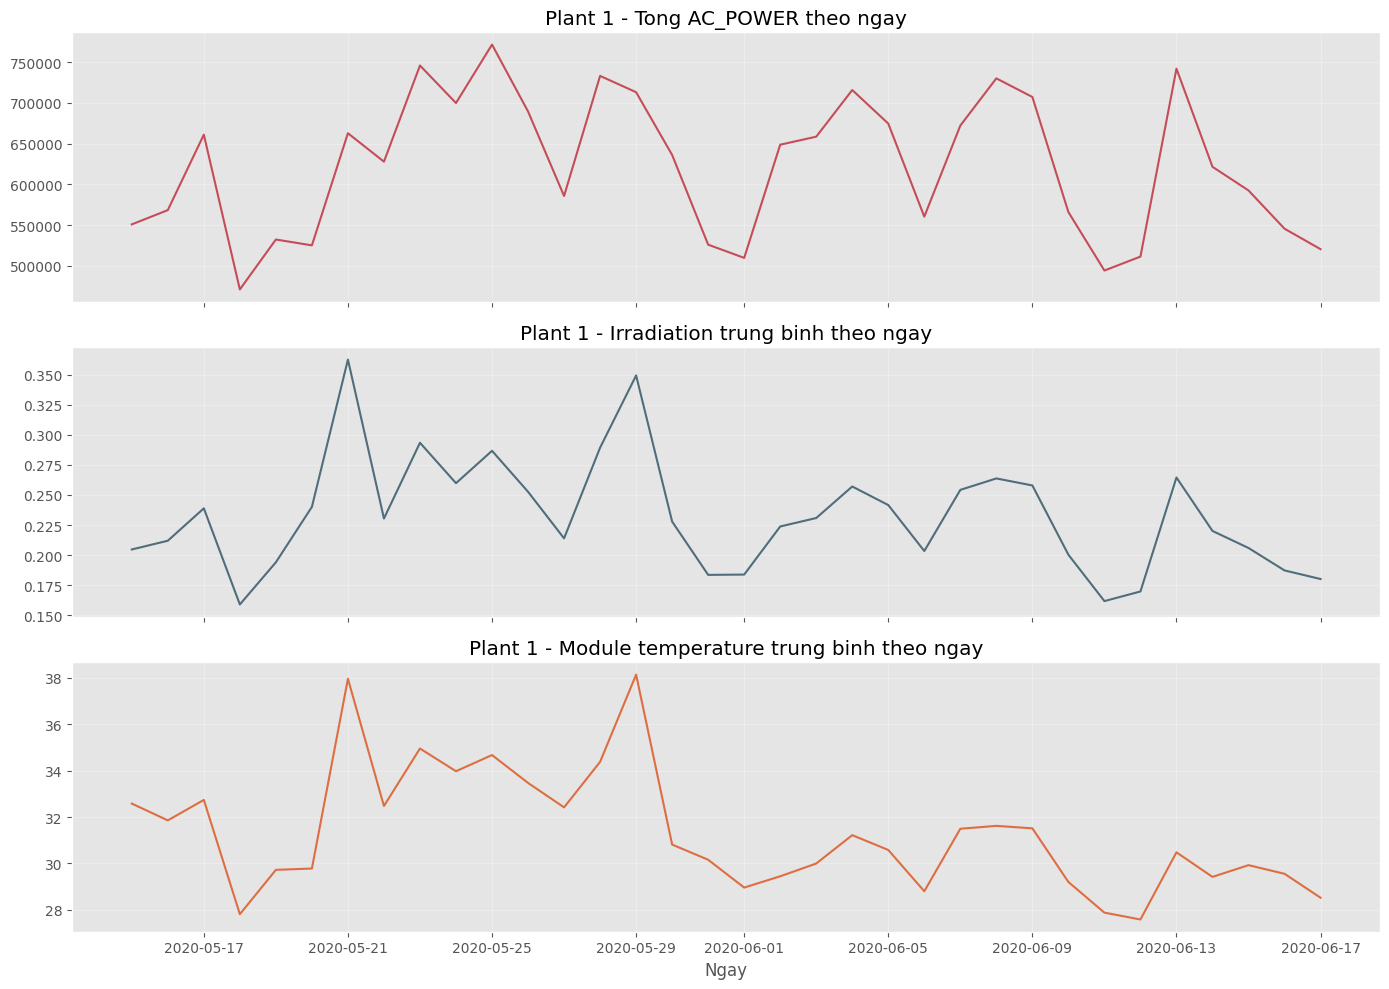

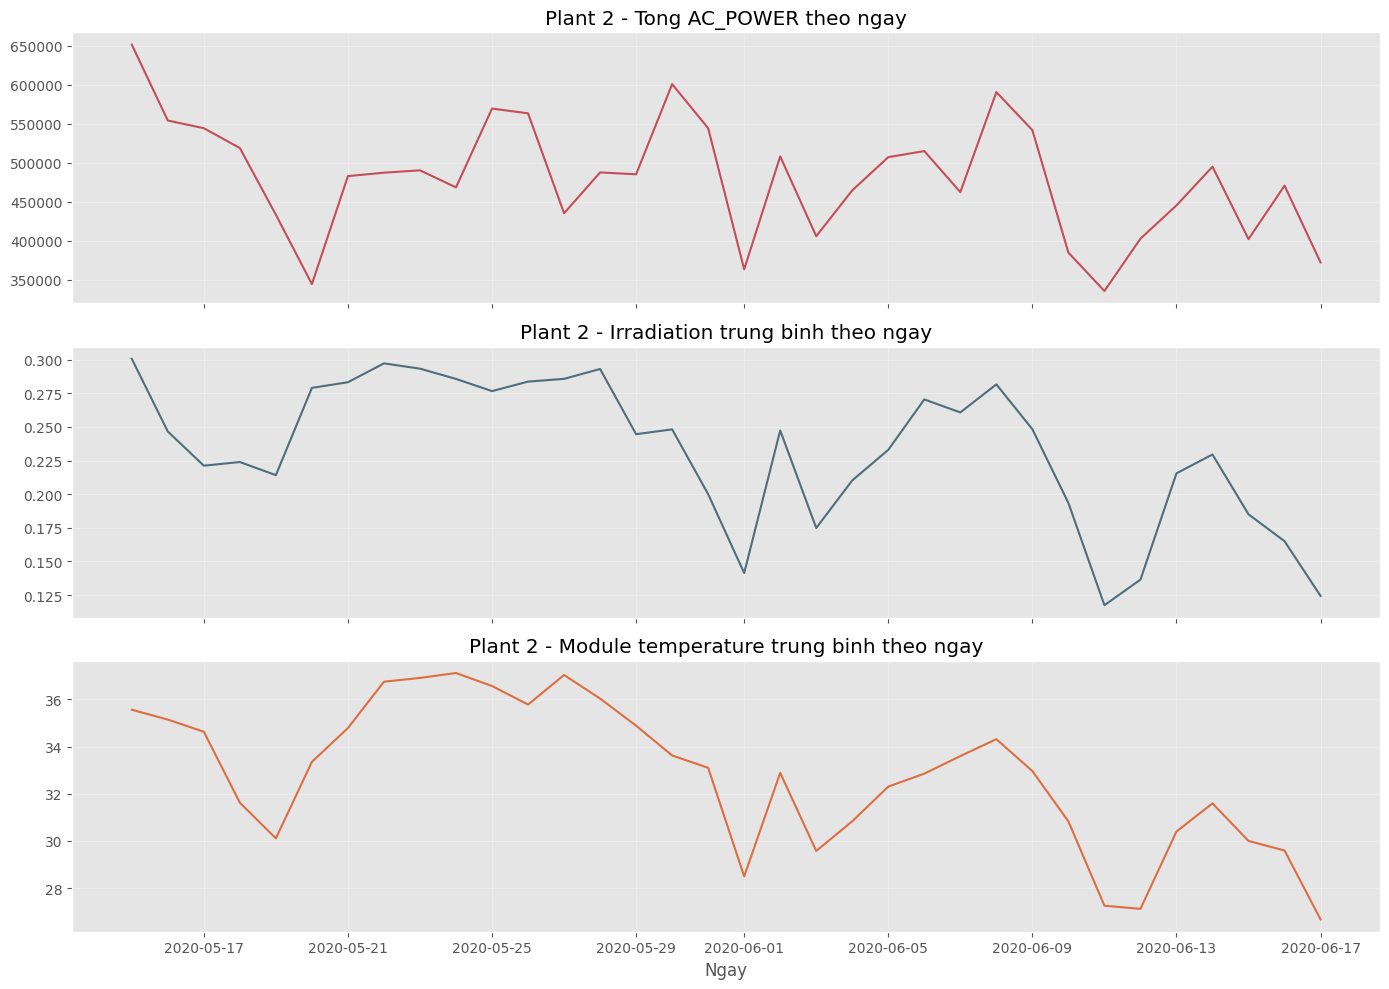

In [6]:
def plot_daily_summary(merged_df: pd.DataFrame, plant_no: int):
    temp = merged_df.copy()
    temp['DATE'] = temp['DATE_TIME'].dt.floor('D')
    daily = temp.groupby('DATE', as_index=False).agg(
        AC_POWER_TOTAL=('AC_POWER_TOTAL', 'sum'),
        IRRADIATION=('IRRADIATION', 'mean'),
        MODULE_TEMPERATURE=('MODULE_TEMPERATURE', 'mean')
    )

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(daily['DATE'], daily['AC_POWER_TOTAL'], color='#c44d58')
    axes[0].set_title(f'Plant {plant_no} - Tong AC_POWER theo ngay')
    axes[1].plot(daily['DATE'], daily['IRRADIATION'], color='#4f6d7a')
    axes[1].set_title(f'Plant {plant_no} - Irradiation trung binh theo ngay')
    axes[2].plot(daily['DATE'], daily['MODULE_TEMPERATURE'], color='#dd6e42')
    axes[2].set_title(f'Plant {plant_no} - Module temperature trung binh theo ngay')
    axes[2].set_xlabel('Ngay')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_daily_summary(plant_1_merged, 1)
plot_daily_summary(plant_2_merged, 2)

## 6. Chọn đặc trưng và chuẩn hóa dữ liệu

LSTM làm việc tốt hơn khi dữ liệu đầu vào đã được scale về cùng một khoảng giá trị. Ở đây ta dùng `MinMaxScaler` để đưa các đặc trưng và biến mục tiêu về khoảng `[0, 1]`.

Ta xây dựng mô hình dự đoán chung cho cả hai nhà máy, nên `PLANT_NO` cũng được đưa vào như một đặc trưng đầu vào. Các đặc trưng được chọn gồm:
- `PLANT_NO`
- `IRRADIATION`
- `AMBIENT_TEMPERATURE`
- `MODULE_TEMPERATURE`
- `DC_POWER_TOTAL`
- `ACTIVE_SOURCE_COUNT`
- `HOUR_SIN`, `HOUR_COS`
- `DAYOFWEEK`, `DAYOFYEAR`, `IS_DAYLIGHT`

Biến mục tiêu là `AC_POWER_TOTAL`.

In [7]:
feature_columns = [
    'PLANT_NO',
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'DC_POWER_TOTAL',
    'ACTIVE_SOURCE_COUNT',
    'HOUR_SIN',
    'HOUR_COS',
    'DAYOFWEEK',
    'DAYOFYEAR',
    'IS_DAYLIGHT'
]
target_column = 'AC_POWER_TOTAL'

model_df = all_merged.dropna(subset=['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']).copy()
model_df = model_df.sort_values(['PLANT_NO', 'DATE_TIME']).reset_index(drop=True)

model_df[feature_columns + [target_column]].head()

,PLANT_NO,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER_TOTAL,ACTIVE_SOURCE_COUNT,HOUR_SIN,HOUR_COS,DAYOFWEEK,DAYOFYEAR,IS_DAYLIGHT,AC_POWER_TOTAL
0,1,0.0000,25.1843,22.8575,0.0000,21,0.0000,1.0000,4,136,0,0.0000
1,1,0.0000,25.0846,22.7617,0.0000,21,0.0654,0.9979,4,136,0,0.0000
2,1,0.0000,24.9358,22.5923,0.0000,21,0.1305,0.9914,4,136,0,0.0000
3,1,0.0000,24.8461,22.3609,0.0000,21,0.1951,0.9808,4,136,0,0.0000
4,1,0.0000,24.6215,22.1654,0.0000,22,0.2588,0.9659,4,136,0,0.0000


## 7. Tạo dữ liệu chuỗi bằng sliding window

Đây là bước khác biệt nhất giữa mô hình LSTM và mô hình tabular thông thường.

Ta không đưa từng dòng dữ liệu độc lập vào mô hình, mà tạo các chuỗi liên tiếp có độ dài cố định. Ví dụ nếu `lookback = 12`, mỗi mẫu sẽ gồm 12 mốc thời gian gần nhất, tương đương 3 giờ dữ liệu nếu mỗi mốc cách nhau 15 phút.

Với cách làm này:
- `X[i]` là ma trận kích thước `(lookback, n_features)`.
- `y[i]` là giá trị `AC_POWER_TOTAL` tại bước kế tiếp ngay sau chuỗi đó.

Ta tạo sequence riêng cho từng plant để tránh việc chuỗi bị nối sai giữa cuối Plant 1 và đầu Plant 2.

In [8]:
lookback = 12
train_ratio = 0.8

def create_sequences_per_plant(df: pd.DataFrame, feature_cols, target_col, lookback=12, train_ratio=0.8):
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []
    test_meta = []

    for plant_no in sorted(df['PLANT_NO'].unique()):
        plant_df = df[df['PLANT_NO'] == plant_no].copy().sort_values('DATE_TIME').reset_index(drop=True)

        split_index = int(len(plant_df) * train_ratio)
        train_df = plant_df.iloc[:split_index].copy()
        test_df = plant_df.iloc[split_index:].copy()

        feature_scaler = MinMaxScaler()
        target_scaler = MinMaxScaler()

        train_features_scaled = feature_scaler.fit_transform(train_df[feature_cols])
        test_features_scaled = feature_scaler.transform(test_df[feature_cols])

        train_target_scaled = target_scaler.fit_transform(train_df[[target_col]])
        test_target_scaled = target_scaler.transform(test_df[[target_col]])

        def build_windows(features_scaled, target_scaled):
            X, y = [], []
            for i in range(lookback, len(features_scaled)):
                X.append(features_scaled[i - lookback:i])
                y.append(target_scaled[i, 0])
            return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

        X_train_plant, y_train_plant = build_windows(train_features_scaled, train_target_scaled)
        X_test_plant, y_test_plant = build_windows(test_features_scaled, test_target_scaled)

        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

        test_meta_plant = test_df.iloc[lookback:].copy()
        test_meta_plant['TARGET_SCALED'] = y_test_plant
        test_meta_plant['PLANT_NO'] = plant_no
        test_meta_plant.attrs['target_scaler'] = target_scaler
        test_meta.append((plant_no, test_meta_plant, target_scaler))

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    return X_train, y_train, X_test, y_test, test_meta

X_train, y_train, X_test, y_test, test_meta = create_sequences_per_plant(
    model_df,
    feature_columns,
    target_column,
    lookback=lookback,
    train_ratio=train_ratio
)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

X_train shape: (5108, 12, 11)
y_train shape: (5108,)
X_test shape : (1260, 12, 11)
y_test shape : (1260,)


## 8. Đưa dữ liệu vào PyTorch DataLoader

Sau khi đã có `X_train`, `y_train`, `X_test`, `y_test`, ta chuyển chúng thành tensor của PyTorch và gói vào `DataLoader`. Đây là chuẩn thực hành trong huấn luyện deep learning vì giúp chia batch và lặp dữ liệu thuận tiện hơn.

Ở đây ta dùng `shuffle=True` cho train loader để mô hình học ổn định hơn trong quá trình tối ưu. Test loader giữ nguyên thứ tự không ảnh hưởng đến việc đánh giá vì ta không cần cập nhật trọng số ở giai đoạn này.

In [9]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

len(train_loader), len(test_loader)

(80, 20)

## 9. Xây dựng mô hình LSTM bằng PyTorch

Kiến trúc mô hình gồm:
- Một lớp `LSTM` nhận chuỗi đầu vào.
- Một lớp `Dropout` để giảm overfitting.
- Một lớp fully connected để dự đoán đầu ra cuối cùng.

Ta chỉ lấy trạng thái ẩn ở bước thời gian cuối cùng của chuỗi vì bài toán ở đây là `many-to-one`: nhiều bước lịch sử để dự đoán một giá trị ở bước kế tiếp.

In [10]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out

input_size = X_train.shape[2]
model = LSTMRegressor(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

LSTMRegressor(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## 10. Huấn luyện mô hình

Trong quá trình huấn luyện, ta theo dõi `train loss` và `validation loss` qua từng epoch. Nếu validation loss không còn giảm, mô hình có thể bắt đầu overfit.

Ta sử dụng chiến lược đơn giản:
- Huấn luyện theo mini-batch.
- Tính loss trên tập train và tập test sau mỗi epoch.
- Lưu lại trạng thái mô hình tốt nhất theo validation loss.

Điều này giúp tránh việc mô hình cuối cùng lại là mô hình có chất lượng kém hơn các epoch trước.

In [11]:
epochs = 25
history = {'train_loss': [], 'val_loss': []}

best_model_state = None
best_val_loss = float('inf')

for epoch in range(1, epochs + 1):
    model.train()
    train_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

model.load_state_dict(best_model_state)
print('Best validation loss:', best_val_loss)

Epoch 01 | Train Loss: 0.024275 | Val Loss: 0.008494
Epoch 02 | Train Loss: 0.010433 | Val Loss: 0.007857
Epoch 03 | Train Loss: 0.009406 | Val Loss: 0.007534
Epoch 04 | Train Loss: 0.008558 | Val Loss: 0.007108
Epoch 05 | Train Loss: 0.007805 | Val Loss: 0.006595
Epoch 06 | Train Loss: 0.007491 | Val Loss: 0.006909
Epoch 07 | Train Loss: 0.006981 | Val Loss: 0.006616
Epoch 08 | Train Loss: 0.007117 | Val Loss: 0.006261
Epoch 09 | Train Loss: 0.006920 | Val Loss: 0.006256
Epoch 10 | Train Loss: 0.006609 | Val Loss: 0.006492
Epoch 11 | Train Loss: 0.006442 | Val Loss: 0.006102
Epoch 12 | Train Loss: 0.006218 | Val Loss: 0.006046
Epoch 13 | Train Loss: 0.006097 | Val Loss: 0.005939
Epoch 14 | Train Loss: 0.005921 | Val Loss: 0.006050
Epoch 15 | Train Loss: 0.005909 | Val Loss: 0.005838
Epoch 16 | Train Loss: 0.006302 | Val Loss: 0.006124
Epoch 17 | Train Loss: 0.005764 | Val Loss: 0.005712
Epoch 18 | Train Loss: 0.005712 | Val Loss: 0.006102
Epoch 19 | Train Loss: 0.005827 | Val Loss: 0.

## 11. Trực quan hóa learning curve

Learning curve cho biết mô hình học như thế nào qua từng epoch. Nếu train loss giảm mạnh nhưng validation loss tăng lên, đó là dấu hiệu overfitting. Nếu cả hai cùng giảm và ổn định, mô hình đang học tương đối tốt.

Biểu đồ này rất hữu ích khi cần điều chỉnh số epoch, hidden size, dropout hoặc learning rate.

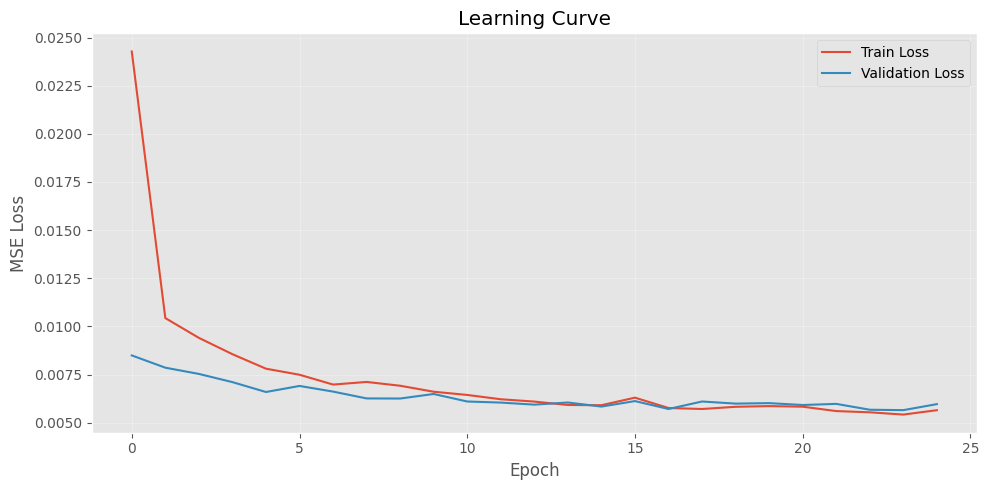

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Dự đoán trên tập test và đảo chuẩn hóa

Mô hình dự đoán trên dữ liệu đã được scale, nên để diễn giải kết quả một cách thực tế, ta cần inverse transform về đơn vị gốc của `AC_POWER_TOTAL`.

Vì mỗi plant được scale riêng trong quá trình tạo sequence, ta cũng cần inverse transform riêng cho từng plant. Đây là lý do `test_meta` lưu kèm `target_scaler` cho từng nhà máy.

In [13]:
model.eval()
all_predictions_scaled = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        pred_batch = model(X_batch).cpu().numpy().reshape(-1)
        all_predictions_scaled.append(pred_batch)

all_predictions_scaled = np.concatenate(all_predictions_scaled)
all_predictions_scaled[:5]

array([0.6233358 , 0.5855168 , 0.49403518, 0.5142553 , 0.5220801 ],
      dtype=float32)

In [14]:
prediction_frames = []
cursor = 0

for plant_no, meta_df, target_scaler in test_meta:
    n_rows = len(meta_df)
    pred_scaled = all_predictions_scaled[cursor:cursor + n_rows]
    cursor += n_rows

    temp = meta_df.copy()
    temp['PREDICTED_SCALED'] = pred_scaled
    temp['PREDICTED_AC_POWER'] = target_scaler.inverse_transform(temp[['PREDICTED_SCALED']])
    temp['ACTUAL_AC_POWER'] = temp['AC_POWER_TOTAL']
    prediction_frames.append(temp)

predictions_df = pd.concat(prediction_frames, ignore_index=True)
predictions_df[['DATE_TIME', 'PLANT_NO', 'ACTUAL_AC_POWER', 'PREDICTED_AC_POWER']].head()

,DATE_TIME,PLANT_NO,ACTUAL_AC_POWER,PREDICTED_AC_POWER
0,2020-06-11 12:30:00,1,"17,050.2161","18,170.3711"
1,2020-06-11 12:45:00,1,"12,529.1107","17,067.9395"
2,2020-06-11 13:00:00,1,"14,581.6714","14,401.2305"
3,2020-06-11 13:15:00,1,"15,706.0875","14,990.6504"
4,2020-06-11 13:30:00,1,"10,412.4286","15,218.7461"


## 13. Đánh giá mô hình bằng MAE, RMSE, R2

Các chỉ số đánh giá được tính trên giá trị đã đảo chuẩn hóa, tức là ở cùng đơn vị gốc với sản lượng điện. Điều này giúp kết quả dễ hiểu và dễ đưa vào báo cáo.

Ta đánh giá:
- Toàn bộ test set.
- Từng plant riêng.

Nếu chất lượng giữa Plant 1 và Plant 2 chênh lệch lớn, đó là tín hiệu cho thấy một mô hình chung có thể chưa phản ánh tốt sự khác biệt giữa hai nhà máy.

In [15]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

metrics = []
metrics.append({
    'scope': 'overall',
    **regression_metrics(predictions_df['ACTUAL_AC_POWER'], predictions_df['PREDICTED_AC_POWER'])
})

for plant_no in sorted(predictions_df['PLANT_NO'].unique()):
    temp = predictions_df[predictions_df['PLANT_NO'] == plant_no]
    metrics.append({
        'scope': f'plant_{plant_no}',
        **regression_metrics(temp['ACTUAL_AC_POWER'], temp['PREDICTED_AC_POWER'])
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,scope,MAE,RMSE,R2
0,overall,"1,090.3497","2,053.7916",0.9108
1,plant_1,"1,068.9647","2,024.3054",0.9351
2,plant_2,"1,111.0664","2,081.9581",0.8590


## 14. Trực quan hóa kết quả dự đoán

Biểu đồ dưới đây cho phép so sánh trực tiếp đường dự đoán và đường thực tế trên tập test. Đây là cách đánh giá trực quan rất hiệu quả trong bài toán chuỗi thời gian.

Khi phân tích biểu đồ, cần chú ý:
- Mô hình có bắt được các đỉnh công suất trong ban ngày không.
- Mô hình có dự đoán sát vùng gần bằng 0 vào ban đêm không.
- Có những giai đoạn nào mô hình dự đoán lệch đáng kể so với thực tế.

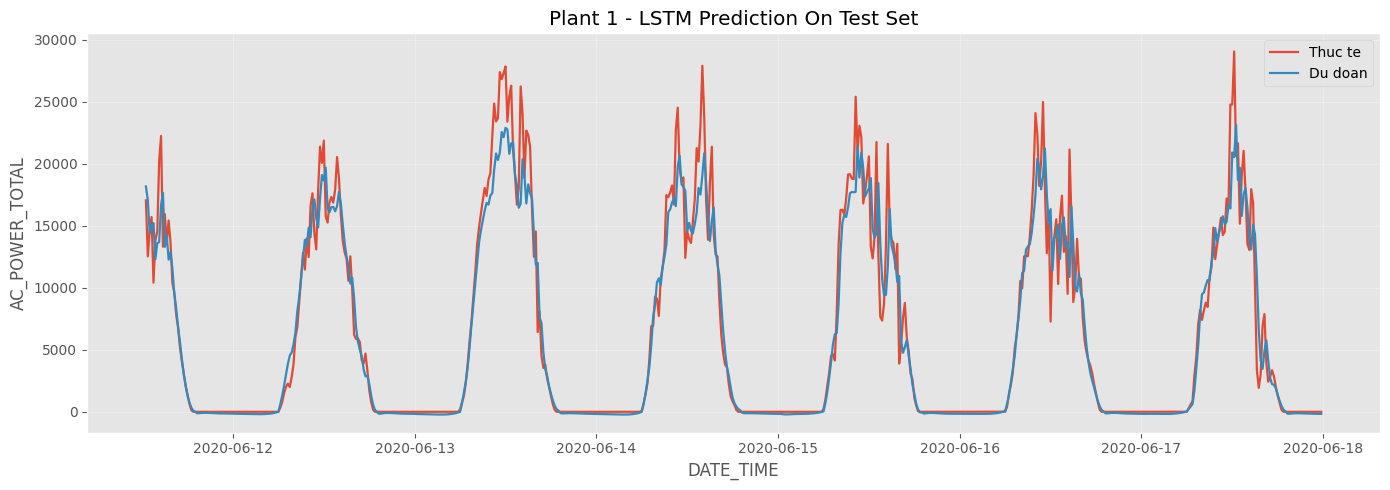

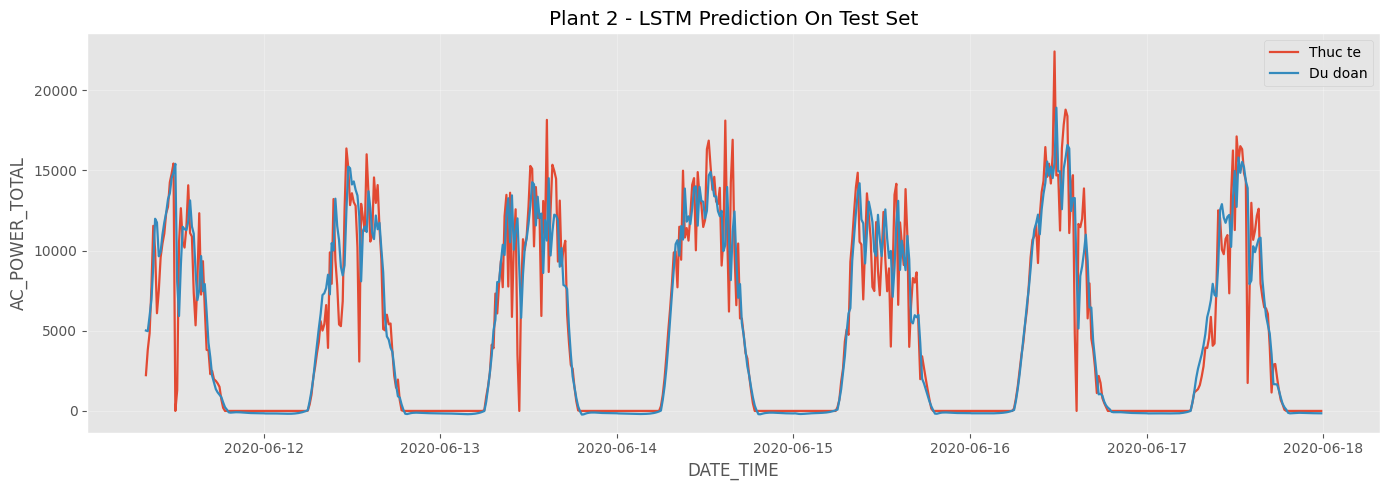

In [16]:
def plot_predictions(pred_df: pd.DataFrame, plant_no: int):
    temp = pred_df[pred_df['PLANT_NO'] == plant_no].copy().sort_values('DATE_TIME')
    plt.figure(figsize=(14, 5))
    plt.plot(temp['DATE_TIME'], temp['ACTUAL_AC_POWER'], label='Thuc te', linewidth=1.6)
    plt.plot(temp['DATE_TIME'], temp['PREDICTED_AC_POWER'], label='Du doan', linewidth=1.6)
    plt.title(f'Plant {plant_no} - LSTM Prediction On Test Set')
    plt.xlabel('DATE_TIME')
    plt.ylabel('AC_POWER_TOTAL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_predictions(predictions_df, 1)
plot_predictions(predictions_df, 2)

## 15. So sánh nhanh thực tế và dự đoán bằng scatter plot

Scatter plot giữa giá trị thực và giá trị dự đoán giúp nhìn rõ mức độ bám sát tổng thể. Nếu các điểm nằm gần đường chéo, mô hình có chất lượng tốt. Nếu các điểm phân tán mạnh, mô hình còn sai số lớn.

Biểu đồ này bổ sung cho line plot: line plot tốt để xem theo thời gian, còn scatter plot tốt để xem độ khớp tổng thể.

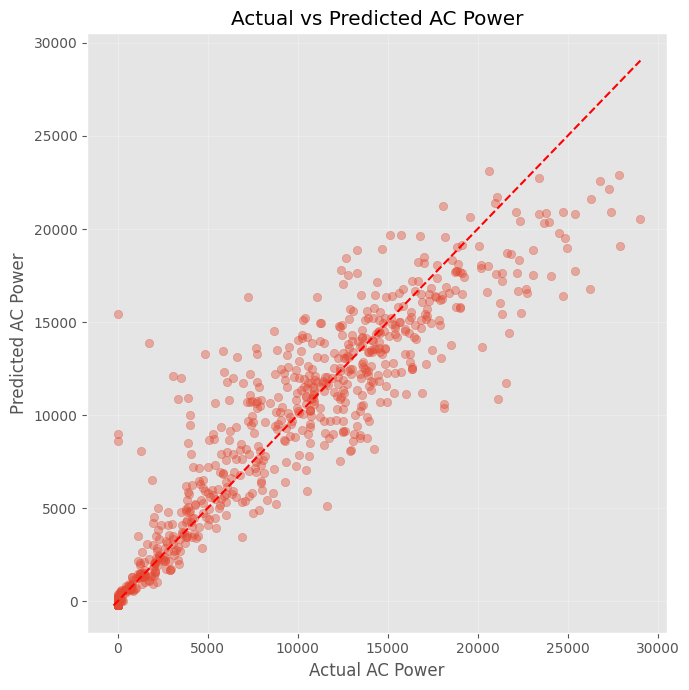

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(predictions_df['ACTUAL_AC_POWER'], predictions_df['PREDICTED_AC_POWER'], alpha=0.4)
min_val = min(predictions_df['ACTUAL_AC_POWER'].min(), predictions_df['PREDICTED_AC_POWER'].min())
max_val = max(predictions_df['ACTUAL_AC_POWER'].max(), predictions_df['PREDICTED_AC_POWER'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.title('Actual vs Predicted AC Power')
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Lưu kết quả để phục vụ báo cáo

Sau khi huấn luyện và đánh giá mô hình, ta lưu lại các file đầu ra để tiện cho việc trình bày hoặc dùng lại ở bước phân tích sau. Các file quan trọng gồm:
- Dữ liệu sau merge.
- Bảng dự đoán trên tập test.
- Bảng metric.

Cách lưu này giúp notebook vừa là nơi phân tích, vừa là pipeline tái sử dụng kết quả.

In [18]:
plant_1_merged.to_csv(OUTPUT_DIR / 'plant_1_merged_for_lstm.csv', index=False)
plant_2_merged.to_csv(OUTPUT_DIR / 'plant_2_merged_for_lstm.csv', index=False)
all_merged.to_csv(OUTPUT_DIR / 'all_plants_merged_for_lstm.csv', index=False)
predictions_df.to_csv(OUTPUT_DIR / 'lstm_predictions.csv', index=False)
metrics_df.to_csv(OUTPUT_DIR / 'lstm_metrics.csv', index=False)

print('Saved outputs to:', OUTPUT_DIR)

Saved outputs to: z:\DOCUMENTS\KPDL\Prj_gr13\outputs


## 17. Kết luận và hướng mở rộng

Notebook này minh họa cách áp dụng LSTM cho bài toán dự đoán sản lượng điện mặt trời. Điểm quan trọng nhất là phải chuyển dữ liệu từ dạng bảng sang dạng chuỗi bằng sliding window. Đây là khác biệt nền tảng giữa LSTM và các mô hình machine learning truyền thống.

Một số hướng mở rộng:
- Thử nhiều giá trị `lookback` khác nhau như 8, 12, 24.
- Huấn luyện riêng một mô hình cho từng plant thay vì mô hình chung.
- Dự đoán nhiều bước tương lai thay vì chỉ 1 bước kế tiếp.
- So sánh LSTM với GRU hoặc Temporal Convolutional Network.
- Kết hợp thêm các lag feature của `AC_POWER_TOTAL` hoặc `IRRADIATION` để tăng khả năng học xu hướng.